In [18]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [19]:
X=torch.linspace(1,50,50).reshape(-1,1)

In [20]:
torch.manual_seed(71)
e=torch.randint(-8,9,(50,1),dtype=torch.float)

In [21]:
Y=2*X+1+e

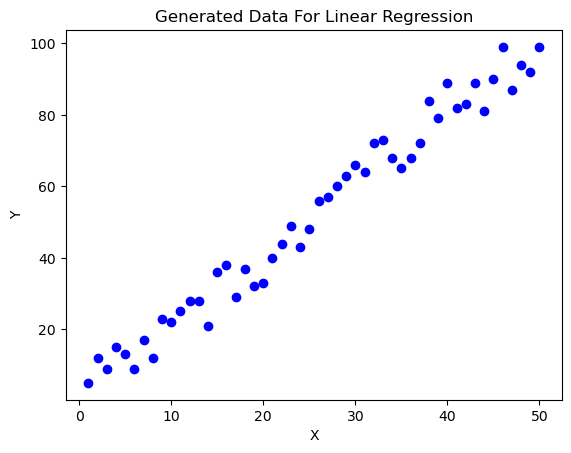

In [23]:
plt.scatter(X.numpy(),Y.numpy(),color='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Generated Data For Linear Regression')
plt.show()

In [24]:
class Model(nn.Module):
  def __init__(self,in_features,out_features):
    super().__init__()
    self.linear=nn.Linear(in_features,out_features)

  def forward(self,x):
    return self.linear(x)

In [25]:
torch.manual_seed(59)

In [26]:
model=Model(1,1)

In [27]:
print(model)

Model(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [28]:
print('Weight:',model.linear.weight.item())
print('Bias:',model.linear.bias.item())

Weight: 0.10597813129425049
Bias: 0.9637961387634277


In [29]:
loss_function=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.0001)

In [30]:
epochs=50
losses=[]
for epoch in range(1,epochs+1):
  optimizer.zero_grad()
  y_pred=model(X)
  loss=loss_function(y_pred,Y)
  losses.append(loss.item())
  loss.backward()
  optimizer.step()
  print(f"epoch: {epoch:2} loss: {loss.item():10.08f}  weight: {model.linear.weight.item():10.08f}  bias: {model.linear.bias.item():10.08f}")


epoch:  1 loss: 3057.21679688  weight: 0.42887032  bias: 0.97346288
epoch:  2 loss: 2103.35449219  weight: 0.69627261  bias: 0.98148096
epoch:  3 loss: 1449.16748047  weight: 0.91772103  bias: 0.98813367
epoch:  4 loss: 1000.50634766  weight: 1.10111284  bias: 0.99365568
epoch:  5 loss: 692.80102539  weight: 1.25298810  bias: 0.99824125
epoch:  6 loss: 481.76757812  weight: 1.37876296  bias: 1.00205135
epoch:  7 loss: 337.03448486  weight: 1.48292291  bias: 1.00521922
epoch:  8 loss: 237.77218628  weight: 1.56918240  bias: 1.00785530
epoch:  9 loss: 169.69511414  weight: 1.64061773  bias: 1.01005089
epoch: 10 loss: 123.00582123  weight: 1.69977641  bias: 1.01188171
epoch: 11 loss: 90.98486328  weight: 1.74876821  bias: 1.01341045
epoch: 12 loss: 69.02390289  weight: 1.78934026  bias: 1.01468909
epoch: 13 loss: 53.96244812  weight: 1.82293963  bias: 1.01576054
epoch: 14 loss: 43.63278198  weight: 1.85076451  bias: 1.01666045
epoch: 15 loss: 36.54840851  weight: 1.87380731  bias: 1.01741

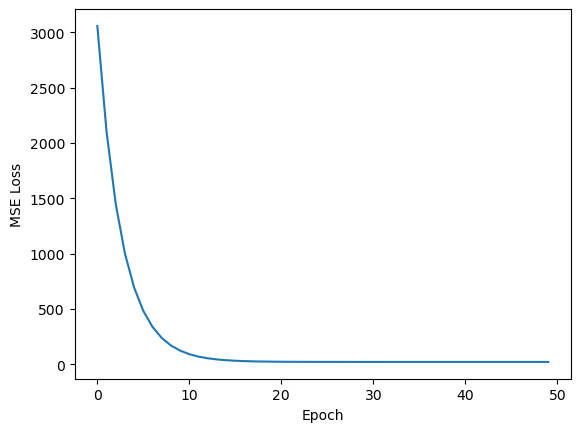

In [31]:
plt.plot(range(epochs),losses)
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.show()

In [32]:
final_weight=model.linear.weight.item()
final_bias=model.linear.bias.item()
print(f"\nFinal Weight : {final_weight:.8f} ,Final Bias: {final_bias}")


Final Weight : 1.98463321 ,Final Bias: 1.0232683420181274


In [33]:
x1=torch.tensor([X.min().item(),X.max().item()])
y1=x1*final_weight+final_bias

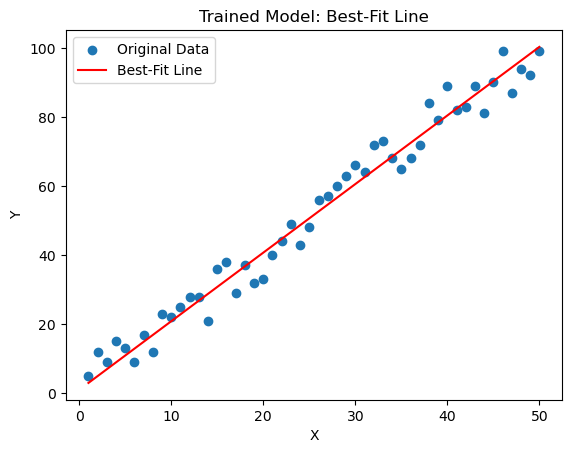

In [34]:
plt.scatter(X,Y,label='Original Data')
plt.plot(x1,y1,'r',label='Best-Fit Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Trained Model: Best-Fit Line')
plt.legend()
plt.show()

In [35]:
x_new=torch.tensor([[120.0]])
y_new_pred=model(x_new).item()
print(f"Prediction for x = 120 : {y_new_pred:.8f}")

Prediction for x = 120 : 239.17926025
